In [1]:
# ============================================================
# Import required libraries
# ============================================================

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [2]:
# ============================================================
# Add project root so notebook can import project modules
# ============================================================

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

C:\Users\Lenovo\Desktop\meetscribe


In [3]:
# ============================================================
# Import the same modules used by the website
# ============================================================

from ml_mom.transcript_parser import parse_transcript
from ml_mom.preprocessing import preprocess_transcript
from ml_mom.feature_extraction import extract_sentence_features
from ml_mom.embeddings import EmbeddingService

In [4]:
# ============================================================
# Read one transcript from dataset
# ============================================================

transcript_path = project_root / "datasets" / "raw_transcripts" / "meeting11.txt"

with open(transcript_path, "r", encoding="utf-8") as file:
    transcript = file.read()

print(transcript[:800])

Participants

Rohan (Client)
Simran (Business Analyst)
Kunal (Developer)
Sneha (UI Designer)

[11:00:08] Rohan: Good morning.

[11:00:20] Simran: Thanks everyone for joining.

[11:00:40] Rohan: We want users to receive meeting summaries automatically by email.

[11:01:05] Kunal: That's technically possible.

[11:01:25] Sneha: Should users be able to customize the email template?

[11:01:50] Rohan: Yes, customization would be useful.

[11:02:20] Simran: Should summaries also include action items?

[11:02:45] Rohan: Definitely.

[11:03:05] Kunal: We can also attach the transcript as a PDF.

[11:03:30] Sneha: That would improve usability.

[11:04:00] Simran: Do we need multilingual support?

[11:04:20] Rohan: Not in Phase 1.

[11:04:45] Simran: Okay, multilingual support will be moved to the 


In [5]:
# ============================================================
# Convert transcript into speaker turns
# ============================================================

parsed = parse_transcript(transcript)

print("Transcript Valid :", parsed.is_valid)
print("Speaker Turns :", len(parsed.turns))

Transcript Valid : True
Speaker Turns : 19


In [6]:
# ============================================================
# Clean transcript before feature extraction
# ============================================================

clean_turns = preprocess_transcript(parsed.turns)

print("Clean Turns :", len(clean_turns))

Clean Turns : 19


In [7]:
# ============================================================
# Convert transcript into sentence features
# ============================================================

sentence_features = extract_sentence_features(clean_turns)

print("Sentence Features :", len(sentence_features))

Sentence Features : 19


In [8]:
# ============================================================
# Generate sentence embeddings using all-MiniLM-L6-v2
# ============================================================

embedding_service = EmbeddingService()

embedding_result = embedding_service.generate_embeddings(sentence_features)

embeddings = np.array(
    [item.embedding_vector for item in embedding_result.embeddings]
)

print("Embedding Shape :", embeddings.shape)

c:\Users\Lenovo\Desktop\meetscribe\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2003.98it/s]


Embedding Shape : (19, 384)


In [9]:
# ============================================================
# Reduce 384-dimensional embeddings to 2 dimensions
# ============================================================

pca = PCA(n_components=2)

points = pca.fit_transform(embeddings)

print(points.shape)

(19, 2)


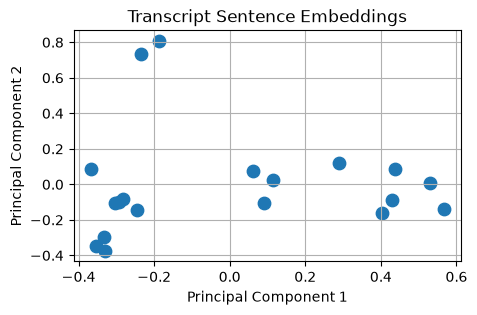

In [10]:
# ============================================================
# Visualize transcript embeddings
# ============================================================

plt.figure(figsize=(5,3))

plt.scatter(
    points[:,0],
    points[:,1],
    s=80
)

plt.title("Transcript Sentence Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

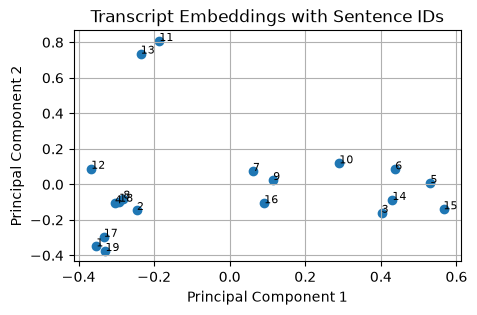

In [13]:
# ============================================================
# Display sentence numbers on graph
# ============================================================

plt.figure(figsize=(5,3))

plt.scatter(points[:,0], points[:,1])

for i, feature in enumerate(sentence_features):

    plt.text(
        points[i,0],
        points[i,1],
        str(i+1),
        fontsize=8
    )

plt.title("Transcript Embeddings with Sentence IDs")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

In [12]:
# ============================================================
# Print sentence number with actual sentence
# ============================================================

for i, feature in enumerate(sentence_features):

    print(f"{i+1}. {feature.original_sentence}")

1. Good morning.
2. Thanks everyone for joining.
3. We want users to receive meeting summaries automatically by email.
4. That's technically possible.
5. Should users be able to customize the email template?
6. Yes, customization would be useful.
7. Should summaries also include action items?
8. Definitely.
9. We can also attach the transcript as a PDF.
10. That would improve usability.
11. Do we need multilingual support?
12. Not in Phase 1.
13. Okay, multilingual support will be moved to the next release.
14. I'll implement automatic email delivery.
15. I'll design the email template.
16. I'll prepare the requirement document.
17. Perfect.
18. Today's decisions are finalized.
19. Meeting closed.
